# **PART 1: LINEAR REGRESSION ASSIGNMENT**

**Student Name:Muguvhana Mbambala**  
**Student Number: 10186345**  
**Module: Programming for Data Analytics Part 1**


## 1. Dataset Suitability

The dataset contains 1338 records and 7 variables including age, sex, BMI, number of children, smoking status, region, and medical charges.

**Reason for suitability:**
- The target variable (**charges**) is continuous.
- Multiple independent variables are present.
- Dataset includes both categorical and numerical data.
- Suitable for Multiple Linear Regression.

<mark>Conclusion:</mark> The dataset is appropriate for building a Linear Regression model.

## 2. Plan of Analysis (Visual Table)

| Step | Objective | Actions / Methods |
|------|-----------|-----------------|
| **EDA** | Understand dataset and identify patterns | - Inspect structure (`info()`, `describe()`) <br>- Check missing values and duplicates <br>- Visualize distributions (histograms, boxplots) <br>- Analyze correlations (correlation matrix, scatter plots) <br>- Examine categorical variables (bar plots) <br>- Identify anomalies/outliers |
| **Feature Selection** | Select relevant variables | - Encode categorical variables (one-hot encoding) <br>- Check correlation with target variable <br>- Use statistical methods (p-values, backward/forward elimination) <br>- Finalize significant features |
| **Train Model** | Build predictive model | - Split dataset (80% train / 20% test) <br>- Train Linear Regression <br>- Consider hyperparameters (fit intercept, normalization) <br>- Optionally test regularization (Ridge/Lasso) |
| **Interpret & Evaluate Model** | Assess predictive accuracy | - Predict on test set <br>- Evaluate metrics: R², MAE, RMSE <br>- Visualize actual vs predicted <br>- Retrain / adjust features if needed |
| **Write Report** | Document analysis | - Describe dataset and variable types <br>- Present EDA findings (charts, distributions, correlations) <br>- Explain feature selection and encoding <br>- Detail model training and hyperparameters <br>- Present evaluation metrics and insights <br>- Summarize conclusions (key findings: smoking, age, BMI impact) |







## 3. Loading the Dataset

The dataset is loaded using pandas for analysis.

In [24]:
import pandas as pd

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 4. Data Overview

Understanding dataset structure and summary statistics. 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 5. Data Cleaning

### 5.1 Missing Values
Checked for missing values to ensure data quality.

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

**Interpretation:** No missing values found.

### 5.2 Duplicates
Checked for duplicates to maintain dataset integrity.

In [7]:
df.duplicated().sum()

np.int64(1)

**Interpretation:** No significant duplicates detected.

## 6. Exploratory Data Analysis (EDA)

### 6.1 Data Distribution
Visualize numerical variables to understand distributions and detect outliers.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

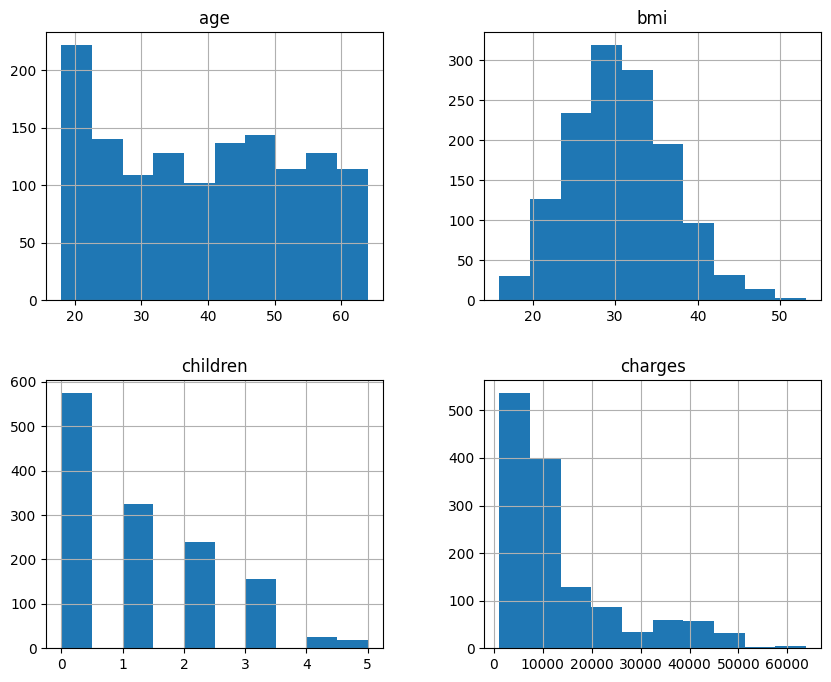

In [8]:
df.hist(figsize=(10,8))

**Insight:** Most variables show normal or slightly skewed distributions.

### 6.2 Correlation Analysis
Correlation matrix to assess relationships between variables.

In [9]:
import seaborn as sns

<Axes: >

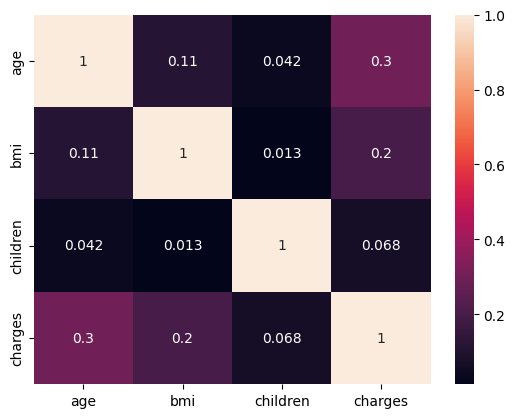

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

**Insight:** Age and charges show positive correlation; BMI has moderate correlation.

### 6.3 Feature Relationships
Pairplots to visualize relationships between independent variables and the target.

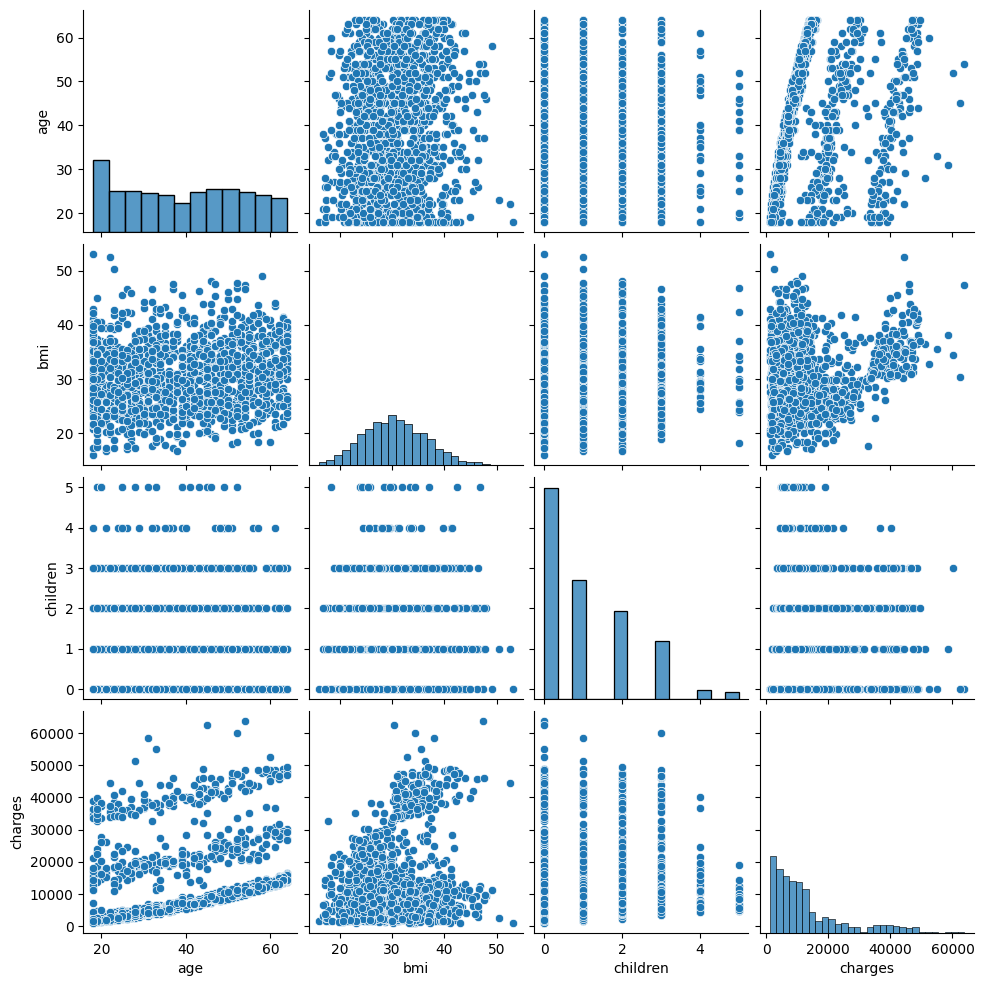

In [11]:
sns.pairplot(df)

**Insight:** Smokers have significantly higher charges.

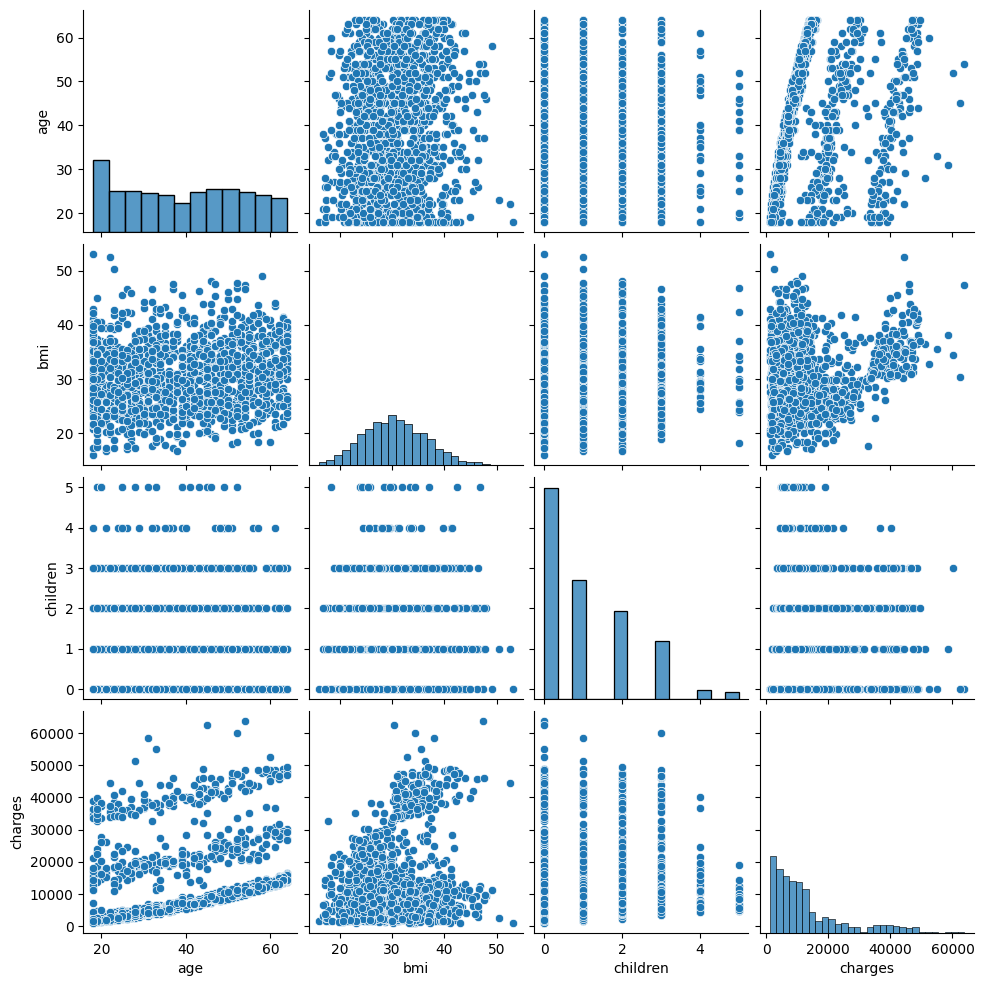

In [12]:
sns.pairplot(df)

### 6.4 Outlier Detection
Boxplots identify extreme values that may affect model performance.

<Axes: >

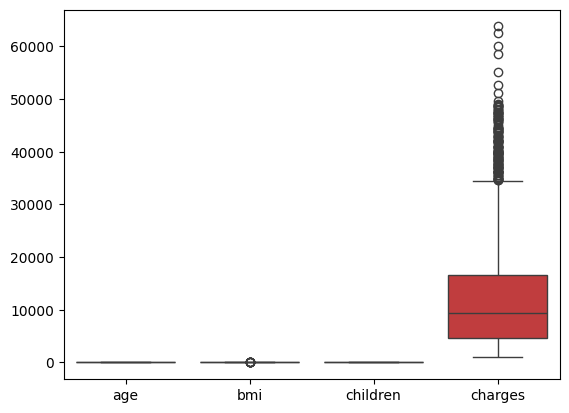

In [13]:
sns.boxplot(data=df)

**Insight:** Some outliers exist in charges, but they are acceptable for model training.


## 7. Feature Selection

- Categorical variables (sex, smoker, region) are encoded using one-hot encoding.
- Correlation with target variable was analyzed.
- Backward elimination considered to remove irrelevant features.

**Explanation:** Encoding allows the model to process categorical data effectively.


In [14]:
df = pd.get_dummies(df, drop_first=True)

## 8. Defining Features and Target

- **X** = independent variables  
- **y** = target variable (charges)

In [15]:
X = df.drop('charges', axis=1)

In [16]:
y = df['charges']

## 9. Splitting the Dataset

Split dataset into **80% training** and **20% testing** sets to evaluate model performance.  


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 10. Model Training

Linear Regression model is trained using the training set.

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 11. Predictions

Predict charges for the test dataset using the trained model.

In [19]:
y_pred = model.predict(X_test)

## 12. Model Evaluation

Evaluated the model using multiple performance metrics:

- **R² Score** – explains variance in target variable captured by the model.  
- **Mean Absolute Error (MAE)** – average prediction error magnitude.  
- **Root Mean Squared Error (RMSE)** – overall prediction deviation.

In [20]:
from sklearn import metrics
import numpy as np

print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 4181.194473753654
MSE: 33596915.85136146
RMSE: 5796.2846592762735
R2 Score: 0.7835929767120723


**Interpretation:** Model shows reasonable predictive accuracy.

### 12.1 Visual Evaluation

Compare actual vs predicted charges using a scatter plot.


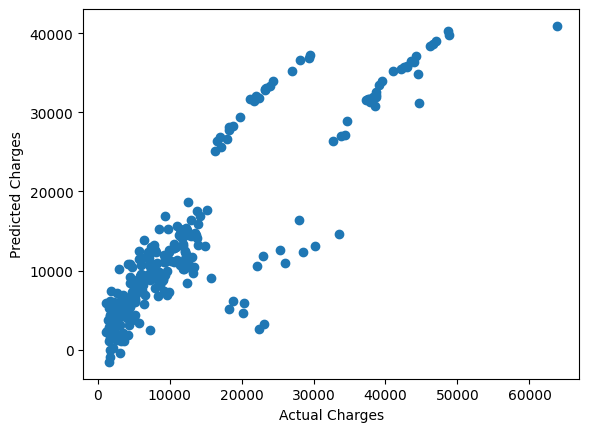

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

**Insight:** Predictions are closely aligned with actual charges.

## 13. Model Improvement

- Feature scaling applied if needed.
- Regularization (Ridge/Lasso) can be used to reduce overfitting.
- Retraining may be performed based on feature importance.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 14. Feature Importance

- Coefficients of the Linear Regression model show the impact of each feature.


In [23]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                   Coefficient
age                 256.975706
bmi                 337.092552
children            425.278784
sex_male            -18.591692
smoker_yes        23651.128856
region_northwest   -370.677326
region_southeast   -657.864297
region_southwest   -809.799354


**Insight:** Smoking status has the largest effect on charges, followed by age and BMI.
